# Marketing Campaign Project

## Goal
Evaluate the A/B testing results and decide which marketing campaign works best.

In [8]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import levene, f_oneway, kruskal, ttest_ind

sns.set_style('whitegrid')

In [9]:

df = pd.read_csv('/Users/alhanoufalmogri/Downloads/WA_Marketing-Campaign.csv')

df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Hypothesis

- **H0:** The mean sales are the same for Promotion 1, Promotion 2, and Promotion 3.
- **H1:** At least one promotion has a different mean sales.

Each location appears for 4 weeks, so we first average sales by location and then compare promotions (we wil do EDA)

In [ ]:
# its the avrage per
location_sales = (
    df.groupby(['LocationID', 'Promotion'], as_index=False)['SalesInThousands']
      .mean()
      .rename(columns={'SalesInThousands': 'AvgSalesInThousands'})
)

summary = location_sales.groupby('Promotion')['AvgSalesInThousands'].agg([ 'mean', 'median', 'std']).round(3)
summary

,mean,median,std
Promotion,,,
1,58.099,56.075,16.028
2,47.329,46.655,14.497
3,55.364,49.852,16.384


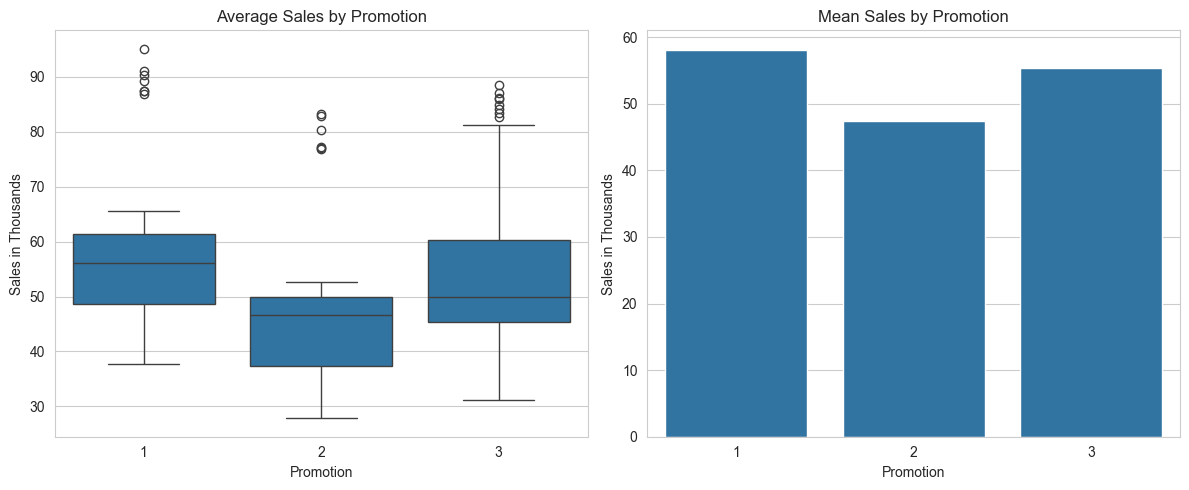

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=location_sales, x='Promotion', y='AvgSalesInThousands', ax=axes[0])
axes[0].set_title('Average Sales by Promotion')
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('Sales in Thousands')

mean_sales = location_sales.groupby('Promotion', as_index=False)['AvgSalesInThousands'].mean()
sns.barplot(data=mean_sales, x='Promotion', y='AvgSalesInThousands', ax=axes[1])
axes[1].set_title('Mean Sales by Promotion')
axes[1].set_xlabel('Promotion')
axes[1].set_ylabel('Sales in Thousands')

plt.tight_layout()
plt.show()

In [12]:
promo_1 = location_sales.loc[location_sales['Promotion'] == 1, 'AvgSalesInThousands']
promo_2 = location_sales.loc[location_sales['Promotion'] == 2, 'AvgSalesInThousands']
promo_3 = location_sales.loc[location_sales['Promotion'] == 3, 'AvgSalesInThousands']

levene_stat, levene_p = levene(promo_1, promo_2, promo_3)
anova_stat, anova_p = f_oneway(promo_1, promo_2, promo_3)
kruskal_stat, kruskal_p = kruskal(promo_1, promo_2, promo_3)

print("Levene p-value:", round(levene_p, 4))
print("ANOVA p-value:", round(anova_p, 4))
print("Kruskal-Wallis p-value:", round(kruskal_p, 4))

Levene p-value: 0.6272
ANOVA p-value: 0.0037
Kruskal-Wallis p-value: 0.0002


In [13]:
# Pairwise comparisons with Bonferroni correction
groups = {
    1: promo_1,
    2: promo_2,
    3: promo_3,
}

results = []
for a, b in itertools.combinations(groups.keys(), 2):
    stat, p = ttest_ind(groups[a], groups[b], equal_var=False)
    p_adj = min(p * 3, 1.0)
    results.append({
        'Comparison': f'Promotion {a} vs {b}',
        'Raw p-value': p,
        'Bonferroni p-value': p_adj,
        'Significant': p_adj < 0.05
    })

pairwise_results = pd.DataFrame(results)
pairwise_results

,Comparison,Raw p-value,Bonferroni p-value,Significant
0,Promotion 1 vs 2,0.001278,0.003833,True
1,Promotion 1 vs 3,0.425912,1.000000,False
2,Promotion 2 vs 3,0.013558,0.040673,True


In [14]:
best_promo = summary['mean'].idxmax()

print('Average sales by promotion:')
print(summary['mean'])

if anova_p < 0.05:
    print('\nDecision: Reject H0.')
    print('There is a statistically significant difference between the promotions.')
else:
    print('\nDecision: Fail to reject H0.')
    print('There is not enough evidence to say the promotions differ.')

print(f'\nBest promotion by average sales: Promotion {best_promo}')

print('\nFinal recommendation:')
print('Promotion 1 is the strongest choice if it has the highest mean sales.')
print('Promotion 2 should not be chosen if it performs significantly worse than the others.')
print('If Promotion 1 and Promotion 3 are close, then cost and ease of implementation can help make the final choice.')

Average sales by promotion:
Promotion
1    58.099
2    47.329
3    55.364
Name: mean, dtype: float64

Decision: Reject H0.
There is a statistically significant difference between the promotions.

Best promotion by average sales: Promotion 1

Final recommendation:
Promotion 1 is the strongest choice if it has the highest mean sales.
Promotion 2 should not be chosen if it performs significantly worse than the others.
If Promotion 1 and Promotion 3 are close, then cost and ease of implementation can help make the final choice.
